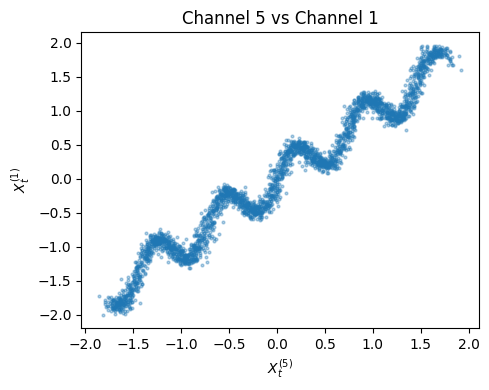

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

T = 3000
M = 8

# latent driver
z = np.linspace(-3, 3, T)
z += 0.08 * rng.normal(size=T)

X = np.zeros((M, T))

# background channels
for m in range(M):
    X[m] = 0.5*z + 0.3*np.sin((m+1)*z) + 0.15*rng.normal(size=T)

# force channels 1 and 5 to have the desired relationship
X[4] = z + 0.08*rng.normal(size=T)                         # x-axis channel
X[0] = z + 0.55*np.sin(5*z) + 0.10*rng.normal(size=T)       # y-axis channel

# optional z-score each channel
X = (X - X.mean(axis=1, keepdims=True)) / X.std(axis=1, keepdims=True)

plt.figure(figsize=(5, 4))
plt.scatter(X[4], X[0], s=4, alpha=0.35)
plt.xlabel(r"$X_t^{(5)}$")
plt.ylabel(r"$X_t^{(1)}$")
plt.title("Channel 5 vs Channel 1")
plt.tight_layout()
plt.show()

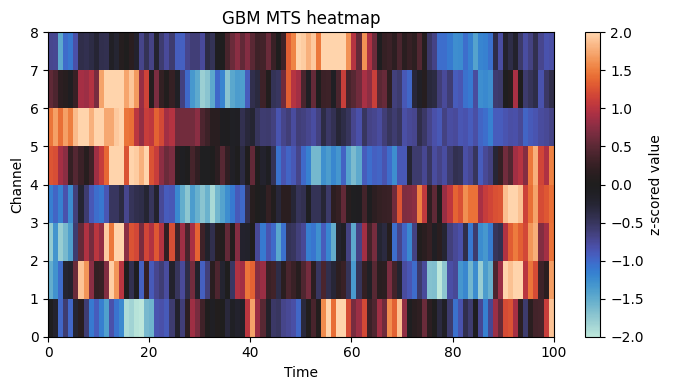

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng()

T = 100
M = 8
dt = 1 / T

mu = 0.4
sigma = 0.7
S0 = 1.0

# correlated GBM shocks
rho = 0.6
corr = rho * np.ones((M, M)) + (1 - rho) * np.eye(M)
L = np.linalg.cholesky(corr)

Z = rng.normal(size=(T - 1, M)) @ L.T

X = np.zeros((T, M))
X[0, :] = S0

for t in range(1, T):
    X[t, :] = X[t-1, :] * np.exp(
        (mu - 0.5 * sigma**2) * dt
        + sigma * np.sqrt(dt) * Z[t-1, :]
    )

# z-score each channel
X = (X - X.mean(axis=0, keepdims=True)) / X.std(axis=0, keepdims=True)

# MTS heatmap: T x M, displayed as channels x time
plt.figure(figsize=(7, 4))
plt.pcolormesh(X.T, shading="auto", cmap="icefire", vmin=-2, vmax=2)
plt.xlabel("Time")
plt.ylabel("Channel")
plt.title("GBM MTS heatmap")
plt.colorbar(label="z-scored value")
plt.tight_layout()
plt.show()

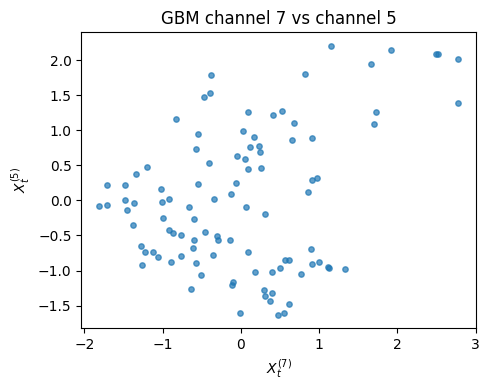

In [61]:
# channel-channel scatter
i, j = 4, 6

plt.figure(figsize=(5, 4))
plt.scatter(X[:, j], X[:, i], s=15, alpha=0.7)
plt.xlabel(fr"$X_t^{{({j+1})}}$")
plt.ylabel(fr"$X_t^{{({i+1})}}$")
plt.title(f"GBM channel {j+1} vs channel {i+1}")
plt.tight_layout()
plt.show()